# Setup e Importações

In [1]:
!pip install optuna optuna-integration scikit-learn seaborn matplotlib lime shap

import os
import gc
import time
import json
import joblib
import numpy as np
import tensorflow as tf
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import f1_score, classification_report

from tensorflow.keras.optimizers import Adam, RMSprop, SGD, AdamW
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K

# ── Reprodutibilidade ──────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Seeds fixados: SEED={SEED}")

# ── Configuração de Datasets ───────────────────────────────────────────────
DATASETS = {
    'newdataset': {
        'train':     '/kaggle/input/newdataset/new_dataset/train',
        'val':       '/kaggle/input/newdataset/new_dataset/val',
        'test':      '/kaggle/input/newdataset/new_dataset/test',
        'n_classes': 5,
    },
    # Para adicionar um novo dataset, descomente e ajuste:
    # 'bracol': {
    #     'train':     '/kaggle/input/bracol/train',
    #     'val':       '/kaggle/input/bracol/val',
    #     'test':      '/kaggle/input/bracol/test',
    #     'n_classes': 4,
    # },
    # 'rocole': {
    #     'train':     '/kaggle/input/rocole/train',
    #     'val':       '/kaggle/input/rocole/val',
    #     'test':      '/kaggle/input/rocole/test',
    #     'n_classes': 4,
    # },
}

DATASET_ATIVO = 'newdataset'

# ── Configuração de Backbones ──────────────────────────────────────────────
BACKBONES = {
    'MobileNetV2': {
        'builder':    tf.keras.applications.MobileNetV2,
        'preprocess': tf.keras.applications.mobilenet_v2.preprocess_input,
        'ft_range':   (20, 140),
    },
    # Para adicionar novos backbones, descomente e ajuste:
    # 'EfficientNetB0': {
    #     'builder':    tf.keras.applications.EfficientNetB0,
    #     'preprocess': tf.keras.applications.efficientnet.preprocess_input,
    #     'ft_range':   (20, 230),
    # },
    # 'ResNet50V2': {
    #     'builder':    tf.keras.applications.ResNet50V2,
    #     'preprocess': tf.keras.applications.resnet_v2.preprocess_input,
    #     'ft_range':   (20, 175),
    # },
    # 'DenseNet121': {
    #     'builder':    tf.keras.applications.DenseNet121,
    #     'preprocess': tf.keras.applications.densenet.preprocess_input,
    #     'ft_range':   (20, 420),
    # },
}

BACKBONE_ATIVO = 'MobileNetV2'

# ── Derivados da configuração ativa ───────────────────────────────────────
N_CLASSES    = DATASETS[DATASET_ATIVO]['n_classes']
NOME_ARQUIVO = f"{BACKBONE_ATIVO}_{DATASET_ATIVO}"

# Acumula métricas de todas as combinações modelo × dataset
resultados_comparativos = []

print(f"Dataset ativo : {DATASET_ATIVO} ({N_CLASSES} classes)")
print(f"Backbone ativo: {BACKBONE_ATIVO}")
print(f"Prefixo de saída: {NOME_ARQUIVO}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 3.7 MB/s eta 0:00:00
Seeds fixados: SEED=42
Dataset ativo : newdataset (5 classes)
Backbone ativo: MobileNetV2
Prefixo de saída: MobileNetV2_newdataset


# Carregamento de Dados e Pesos

In [2]:
cfg_dataset = DATASETS[DATASET_ATIVO]
train_dir   = cfg_dataset['train']
val_dir     = cfg_dataset['val']
test_dir    = cfg_dataset['test']

img_size   = (224, 224)
batch_size = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Treino (embaralhado)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size, label_mode='int', seed=123
)

class_names_geral = train_dataset.class_names

# Validação (SEM embaralhar)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False
)

# Teste (SEM embaralhar)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False
)

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset   = val_dataset.prefetch(AUTOTUNE)
test_dataset  = test_dataset.prefetch(AUTOTUNE)

labels       = np.concatenate([y for x, y in train_dataset], axis=0)
class_counts = Counter(labels)
total        = sum(class_counts.values())

class_weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}
print(f"Classes: {class_names_geral}")
print(f"Pesos das classes: {class_weights}")

Found 1905 files belonging to 5 classes.
Found 408 files belonging to 5 classes.
Found 409 files belonging to 5 classes.
Classes: ['1_health', '2_miner', '3_rust', '4_phoma', '5_cercospora']
Pesos das classes: {3: 1.0793201133144477, 4: 1.4377358490566037, 2: 0.5489913544668588, 1: 0.9202898550724637, 0: 2.1284916201117317}


# Módulo de Data Pipeline

In [3]:
def get_augmentation_layer(trial=None, best_params=None):
    if trial:
        rot = trial.suggest_float("rotation", 0.0, 0.1)
        cont = trial.suggest_float("contrast", 0.0, 0.2)
        bright = trial.suggest_float("brightness", 0.0, 0.2)
        z_h = trial.suggest_float("zoom_height", -0.1, 0.1)
        z_w = trial.suggest_float("zoom_width", -0.1, 0.1)
        t_h = trial.suggest_float("translate_height", 0.0, 0.1)
        t_w = trial.suggest_float("translate_width", 0.0, 0.1)
    else:
        rot = best_params['rotation']
        cont = best_params['contrast']
        bright = best_params['brightness']
        z_h = best_params['zoom_height']
        z_w = best_params['zoom_width']
        t_h = best_params['translate_height']
        t_w = best_params['translate_width']

    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomTranslation(height_factor=t_h, width_factor=t_w),
        tf.keras.layers.RandomZoom(height_factor=(z_h, 0.1), width_factor=(z_w, 0.1)),
        tf.keras.layers.RandomRotation(rot),
        tf.keras.layers.RandomContrast(cont),
        tf.keras.layers.RandomBrightness(bright)
    ])

def apply_augmentation(dataset, aug_layer):
    return dataset.map(lambda x, y: (aug_layer(x, training=True), y), num_parallel_calls=AUTOTUNE)

# Construtor da Arquitetura do Modelo

In [4]:
def create_model(trial, is_final=False, best_params=None, backbone_name=None):
    if backbone_name is None:
        backbone_name = BACKBONE_ATIVO
    cfg_bb = BACKBONES[backbone_name]

    lr       = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)          if trial else best_params['learning_rate']
    use_pre  = trial.suggest_categorical("use_pretrained", [True, False])           if trial else best_params['use_pretrained']
    fine_t   = trial.suggest_categorical("fine_tune", [True, False])                if trial else best_params['fine_tune']
    opt_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "AdamW", "SGD"]) if trial else best_params['optimizer']

    # Optuna decide a QUANTIDADE de camadas densas no topo (1 a 3)
    n_dense_layers = trial.suggest_int("n_dense_layers", 1, 3) if trial else best_params['n_dense_layers']

    # E também o tamanho/dropout de CADA camada de forma independente
    dense_units_per_layer = []
    dropout_per_layer     = []
    for i in range(n_dense_layers):
        if trial:
            units_i = trial.suggest_int(f"dense_units_l{i}", 128, 1024, step=128)
            drop_i  = trial.suggest_float(f"dropout_rate_l{i}", 0.2, 0.6)
        else:
            units_i = best_params[f"dense_units_l{i}"]
            drop_i  = best_params[f"dropout_rate_l{i}"]
        dense_units_per_layer.append(units_i)
        dropout_per_layer.append(drop_i)

    weights_choice = 'imagenet' if use_pre else None

    ft_min, ft_max = cfg_bb['ft_range']
    ft_at = trial.suggest_int("fine_tune_at", ft_min, ft_max, step=20) if trial else best_params['fine_tune_at']

    # Nome fixo "base_model" garante compatibilidade com Grad-CAM independente do backbone
    base_model = cfg_bb['builder'](
        include_top=False, weights=weights_choice, input_shape=(224, 224, 3), name='base_model'
    )

    if fine_t:
        base_model.trainable = True
        for layer in base_model.layers[:ft_at]:
            layer.trainable = False
    else:
        base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3), name='input_imagem')
    x = cfg_bb['preprocess'](inputs)
    x = base_model(x, training=fine_t)
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    # Empilha N blocos Dense -> BatchNorm -> Dropout, conforme decidido pelo Optuna
    for i, (units_i, drop_i) in enumerate(zip(dense_units_per_layer, dropout_per_layer)):
        x = tf.keras.layers.Dense(
            units_i,
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4),
            name=f'dense_features_l{i}'
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f'bn_l{i}')(x)
        x = tf.keras.layers.Dropout(drop_i, name=f'dropout_l{i}')(x)

    outputs = tf.keras.layers.Dense(N_CLASSES, activation='softmax', name='predicao_final')(x)

    model = tf.keras.Model(inputs, outputs)

    if opt_name == "Adam":     optimizer = Adam(lr)
    elif opt_name == "RMSprop": optimizer = RMSprop(lr)
    elif opt_name == "AdamW":   optimizer = AdamW(lr)
    else:                       optimizer = SGD(lr, momentum=0.9)

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Busca do Optuna

In [5]:
from optuna.integration import TFKerasPruningCallback

def objective(trial):
    K.clear_session()

    model = create_model(trial, backbone_name=BACKBONE_ATIVO)
    aug_layer = get_augmentation_layer(trial=trial)
    train_dataset_aug = apply_augmentation(train_dataset, aug_layer)

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    pruning_cb = TFKerasPruningCallback(trial, monitor='val_accuracy')

    model.fit(
        train_dataset_aug,
        validation_data=val_dataset,
        epochs=15,
        callbacks=[early_stop, pruning_cb],
        verbose=0,
        class_weight=class_weights
    )

    y_true = np.concatenate([y for x, y in val_dataset], axis=0)
    y_pred_probs = model.predict(val_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    f1_macro = f1_score(y_true, y_pred, average='macro')

    K.clear_session()
    gc.collect()

    return f1_macro


pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
# TPESampler com seed garante que os trials sejam reproduzíveis
sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(direction="maximize", pruner=pruner, sampler=sampler)
study.optimize(objective, n_trials=60)
print("Melhores parâmetros:", study.best_params)
print(f"Trials completos: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Trials podados: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")

[I 2026-05-19 10:20:05,365] A new study created in memory with name: no-name-d8088a45-6ca0-4864-9e5f-d9c26512c9cb


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[I 2026-05-19 10:24:53,478] Trial 0 finished with value: 0.9267606458675424 and parameters: {'learning_rate': 5.6115164153345e-05, 'use_pretrained': True, 'fine_tune': True, 'optimizer': 'AdamW', 'n_dense_layers': 3, 'dense_units_l0': 128, 'dropout_rate_l0': 0.5879639408647976, 'dense_units_l1': 896, 'dropout_rate_l1': 0.28493564427131046, 'dense_units_l2': 256, 'dropout_rate_l2': 0.27336180394137355, 'fine_tune_at': 60, 'rotation': 0.052475643163223784, 'contrast': 0.08638900372842316, 'brightness': 0.058245828039608386, 'zoom_height': 0.02237057894447589, 'zoom_width': -0.07210122786959164, 'translate_height': 0.029214464853521818, 'translate_width': 0.03663618432936917}. Best is trial 0 with value: 0.9267606458675424.
[I 2026-05-19 10:27:50,651] Trial 1 finished with value: 0.892666415598009 and parameters: {'learning_rate': 8.168455894760161e-05, 'use_pretrained': True, 'fine_tune': False, 'optimizer': 'RMSprop', 'n_dense_layers': 3, 'dense_units_l0': 1024, 'dropout_rate_l0': 0.523

Melhores parâmetros: {'learning_rate': 0.0008262803230062576, 'use_pretrained': True, 'fine_tune': False, 'optimizer': 'RMSprop', 'n_dense_layers': 3, 'dense_units_l0': 256, 'dropout_rate_l0': 0.44935639117743653, 'dense_units_l1': 256, 'dropout_rate_l1': 0.5315172508543945, 'dense_units_l2': 512, 'dropout_rate_l2': 0.469439729325573, 'fine_tune_at': 20, 'rotation': 0.09985624229727276, 'contrast': 0.17163898358463822, 'brightness': 0.15490037461335032, 'zoom_height': 0.07828382890980941, 'zoom_width': -0.04650149036016903, 'translate_height': 0.042106646695153814, 'translate_width': 0.07399035440491436}
Trials completos: 22
Trials podados: 38


In [6]:
# ── Persistência do estudo Optuna e hiperparâmetros ───────────────────────
# Salva o objeto study completo (todos os trials, histórico, etc.)
study_path = f'optuna_study_{NOME_ARQUIVO}.pkl'
joblib.dump(study, study_path)
print(f"Study Optuna salvo em: {study_path}")

# Salva apenas os melhores parâmetros em JSON (legível e portável)
params_path = f'best_params_{NOME_ARQUIVO}.json'
with open(params_path, 'w') as f:
    json.dump(study.best_params, f, indent=2)
print(f"Melhores parâmetros salvos em: {params_path}")
print(json.dumps(study.best_params, indent=2))

Study Optuna salvo em: optuna_study_MobileNetV2_newdataset.pkl
Melhores parâmetros salvos em: best_params_MobileNetV2_newdataset.json
{
  "learning_rate": 0.0008262803230062576,
  "use_pretrained": true,
  "fine_tune": false,
  "optimizer": "RMSprop",
  "n_dense_layers": 3,
  "dense_units_l0": 256,
  "dropout_rate_l0": 0.44935639117743653,
  "dense_units_l1": 256,
  "dropout_rate_l1": 0.5315172508543945,
  "dense_units_l2": 512,
  "dropout_rate_l2": 0.469439729325573,
  "fine_tune_at": 20,
  "rotation": 0.09985624229727276,
  "contrast": 0.17163898358463822,
  "brightness": 0.15490037461335032,
  "zoom_height": 0.07828382890980941,
  "zoom_width": -0.04650149036016903,
  "translate_height": 0.042106646695153814,
  "translate_width": 0.07399035440491436
}


# Treinamento Definitivo

In [7]:
best_params = study.best_params

model = create_model(trial=None, is_final=True, best_params=best_params, backbone_name=BACKBONE_ATIVO)
aug_layer_final = get_augmentation_layer(best_params=best_params)
train_dataset_final = apply_augmentation(train_dataset, aug_layer_final)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)

history = model.fit(
    train_dataset_final,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    class_weight=class_weights
)

# Salva o modelo no formato nativo do Keras (pesos + arquitetura + estado do optimizer)
keras_path = f'{NOME_ARQUIVO}.keras'
model.save(keras_path)
print(f"Modelo salvo em: {keras_path}")

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 312ms/step - accuracy: 0.4659 - loss: 1.7503 - val_accuracy: 0.8162 - val_loss: 0.6397 - learning_rate: 8.2628e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 206ms/step - accuracy: 0.7524 - loss: 0.8253 - val_accuracy: 0.8848 - val_loss: 0.4614 - learning_rate: 8.2628e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 205ms/step - accuracy: 0.8371 - loss: 0.5880 - val_accuracy: 0.9240 - val_loss: 0.4083 - learning_rate: 8.2628e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - accuracy: 0.8472 - loss: 0.6126 - val_accuracy: 0.9069 - val_loss: 0.4708 - learning_rate: 8.2628e-04
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 205ms/step - accuracy: 0.8631 - loss: 0.5634 - val_accuracy: 0.9191 - val_loss: 0.4123 - learning_rate: 8.2628e-04
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 205ms/step - accuracy: 0.8657 - loss: 0.5299 - val_accuracy: 0.9142 - val_loss: 0.4313 - learning_rate: 8.2628e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/ste

# Curvas de Aprendizado (Loss e Acurácia)


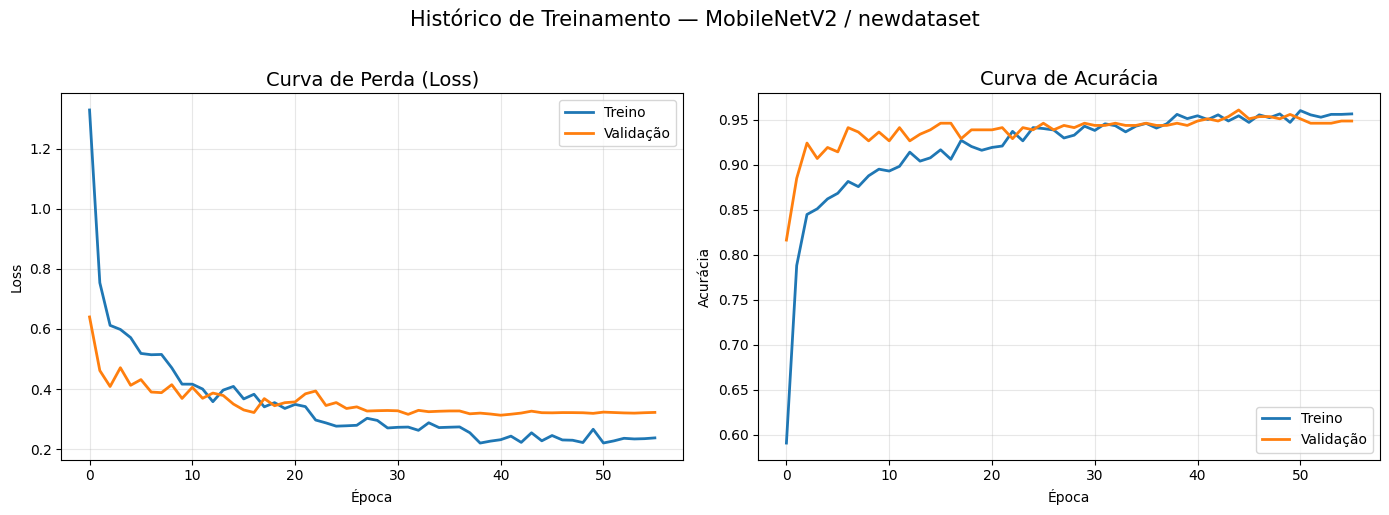

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Loss
axes[0].plot(history.history['loss'], label='Treino', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validação', linewidth=2)
axes[0].set_title('Curva de Perda (Loss)', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de Acurácia
axes[1].plot(history.history['accuracy'], label='Treino', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
axes[1].set_title('Curva de Acurácia', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Histórico de Treinamento — {BACKBONE_ATIVO} / {DATASET_ATIVO}', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f'curvas_aprendizado_{NOME_ARQUIVO}.png', dpi=150, bbox_inches='tight')
plt.show()

# Avaliação Definitiva no Conjunto de Teste

In [9]:
print("Avaliando o modelo final no conjunto de TESTE (dados nunca vistos)...")
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)

print(f"\nAcurácia no Teste: {test_acc:.4f}")
print(f"Perda no Teste: {test_loss:.4f}")

Avaliando o modelo final no conjunto de TESTE (dados nunca vistos)...
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 410ms/step - accuracy: 0.9751 - loss: 0.2014

Acurácia no Teste: 0.9438
Perda no Teste: 0.3176


# Exportador TensorFlow Lite para Flutter

In [10]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

tflite_path = f'{NOME_ARQUIVO}.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"Modelo convertido para TFLite com sucesso! Salvo em: {tflite_path}")

Saved artifact at '/tmp/tmpp7tqmsyn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_imagem')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135318412732272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318393631520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318937149760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318394922160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318393629936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318393624304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318393633984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318393629408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318393633808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135318393621664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13531839362448

# Latência de Inferência (Benchmark Mobile/Offline)

In [11]:
import time
import numpy as np

N_WARMUP = 10   # inferências de aquecimento (descartadas)
N_RUNS   = 100  # inferências medidas

# Pega um batch do test_dataset e extrai uma única imagem para benchmark de 1 imagem por vez
sample_batch = next(iter(test_dataset))[0]          # shape: (batch, 224, 224, 3)
sample_img   = sample_batch[:1]                     # shape: (1, 224, 224, 3)

# Aquecimento (evita penalidade do JIT/XLA na primeira chamada)
for _ in range(N_WARMUP):
    _ = model(sample_img, training=False)

# Medição de latência — imagem única (simula uso mobile)
tempos = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    _ = model(sample_img, training=False)
    tempos.append((time.perf_counter() - t0) * 1000)  # em ms

latencia_media  = np.mean(tempos)
latencia_p95    = np.percentile(tempos, 95)
latencia_std    = np.std(tempos)

print("── Benchmark de Inferência (Keras / CPU+GPU) ──")
print(f"  Latência média  : {latencia_media:.2f} ms")
print(f"  Desvio padrão   : {latencia_std:.2f} ms")
print(f"  Percentil 95    : {latencia_p95:.2f} ms")
print(f"  FPS equivalente : {1000 / latencia_media:.1f} imagens/s")

# ── Latência do modelo TFLite (o que roda no app) ─────────────────────────
tflite_path = f'{NOME_ARQUIVO}.tflite'
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

img_tflite = sample_img.numpy().astype(np.float32)

for _ in range(N_WARMUP):
    interpreter.set_tensor(input_details[0]['index'], img_tflite)
    interpreter.invoke()

tempos_tflite = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    interpreter.set_tensor(input_details[0]['index'], img_tflite)
    interpreter.invoke()
    tempos_tflite.append((time.perf_counter() - t0) * 1000)

lat_tflite_media = np.mean(tempos_tflite)
lat_tflite_p95   = np.percentile(tempos_tflite, 95)

print("\n── Benchmark de Inferência (TFLite quantizado) ──")
print(f"  Latência média  : {lat_tflite_media:.2f} ms")
print(f"  Percentil 95    : {lat_tflite_p95:.2f} ms")
print(f"  FPS equivalente : {1000 / lat_tflite_media:.1f} imagens/s")
print(f"\n  Speedup TFLite vs Keras: {latencia_media / lat_tflite_media:.2f}x")

# Tamanho do arquivo TFLite em disco
tflite_size_kb = os.path.getsize(tflite_path) / 1024
print(f"  Tamanho do modelo TFLite: {tflite_size_kb:.1f} KB ({tflite_size_kb/1024:.2f} MB)")

── Benchmark de Inferência (Keras / CPU+GPU) ──
  Latência média  : 135.59 ms
  Desvio padrão   : 3.77 ms
  Percentil 95    : 140.30 ms
  FPS equivalente : 7.4 imagens/s

── Benchmark de Inferência (TFLite quantizado) ──
  Latência média  : 18.28 ms
  Percentil 95    : 20.88 ms
  FPS equivalente : 54.7 imagens/s

  Speedup TFLite vs Keras: 7.42x
  Tamanho do modelo TFLite: 2978.9 KB (2.91 MB)


# Matriz de confusão e Avaliação Detalhada

Coletando rótulos reais do teste...
Gerando predições com o modelo final...
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 242ms/step


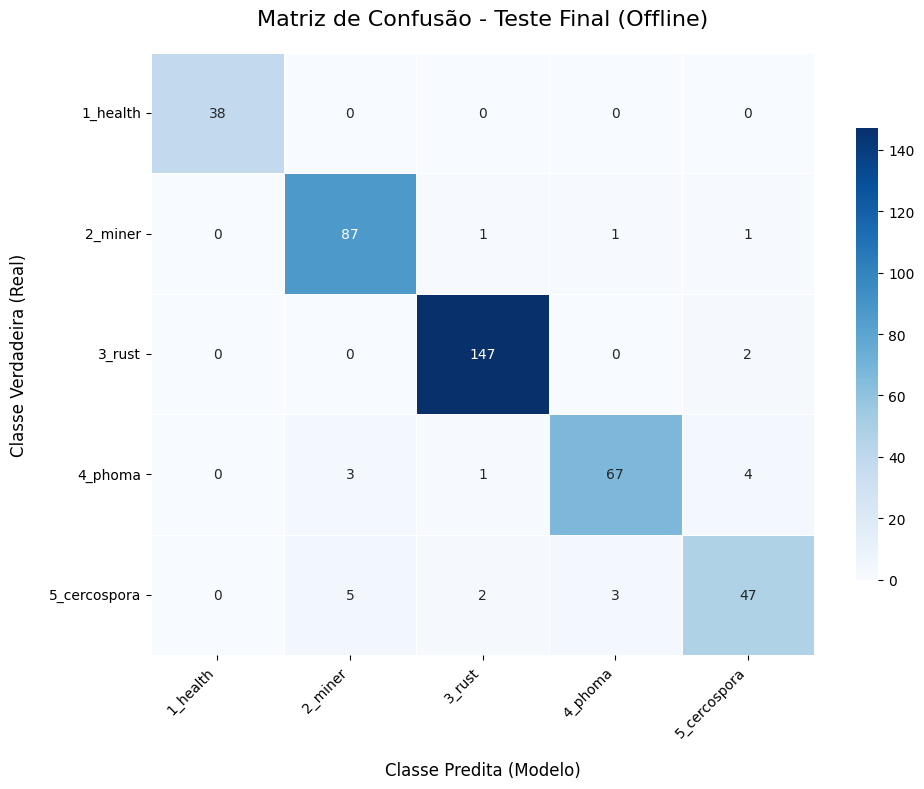


Relatório de Classificação Detalhado (Teste):

              precision    recall  f1-score   support

    1_health       1.00      1.00      1.00        38
     2_miner       0.92      0.97      0.94        90
      3_rust       0.97      0.99      0.98       149
     4_phoma       0.94      0.89      0.92        75
5_cercospora       0.87      0.82      0.85        57

    accuracy                           0.94       409
   macro avg       0.94      0.93      0.94       409
weighted avg       0.94      0.94      0.94       409



In [12]:
# CÉLULA: Matriz de Confusão no Conjunto de Teste
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Coletar os rótulos reais (Ground Truth) do dataset de teste
print("Coletando rótulos reais do teste...")
y_true_test = np.concatenate([y for x, y in test_dataset], axis=0)

# 2. Gerar as predições com o modelo treinado
print("Gerando predições com o modelo final...")
y_pred_probs_test = model.predict(test_dataset)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)

# 3. Calcular a Matriz de Confusão
cm = confusion_matrix(y_true_test, y_pred_test)

# 4. Plotar a Matriz graficamente com Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_geral, yticklabels=class_names_geral,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Matriz de Confusão - Teste Final (Offline)', pad=20, fontsize=16)
plt.ylabel('Classe Verdadeira (Real)', fontsize=12, labelpad=15)
plt.xlabel('Classe Predita (Modelo)', fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Relatório de Classificação (Precision, Recall e F1-Score por classe)
print("\nRelatório de Classificação Detalhado (Teste):\n")
print(classification_report(y_true_test, y_pred_test, target_names=class_names_geral))

# Curvas ROC, Precision-Recall e F1 por Classe


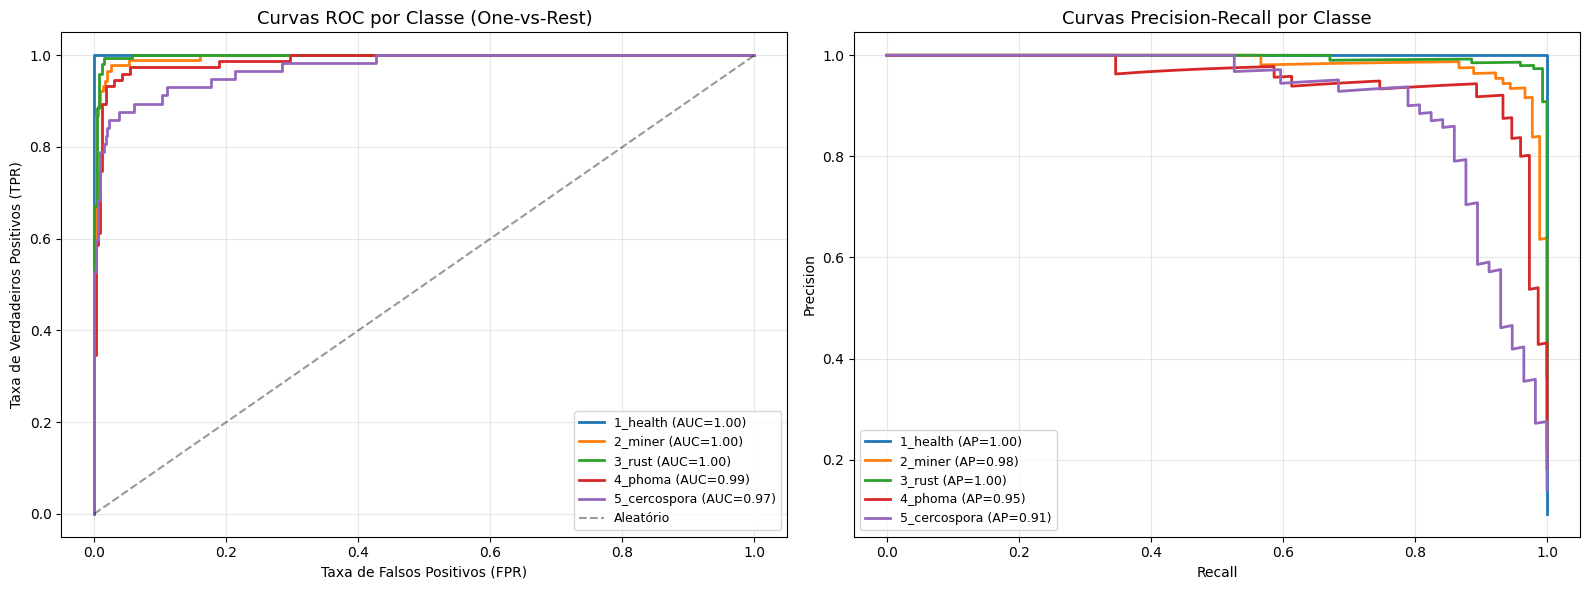

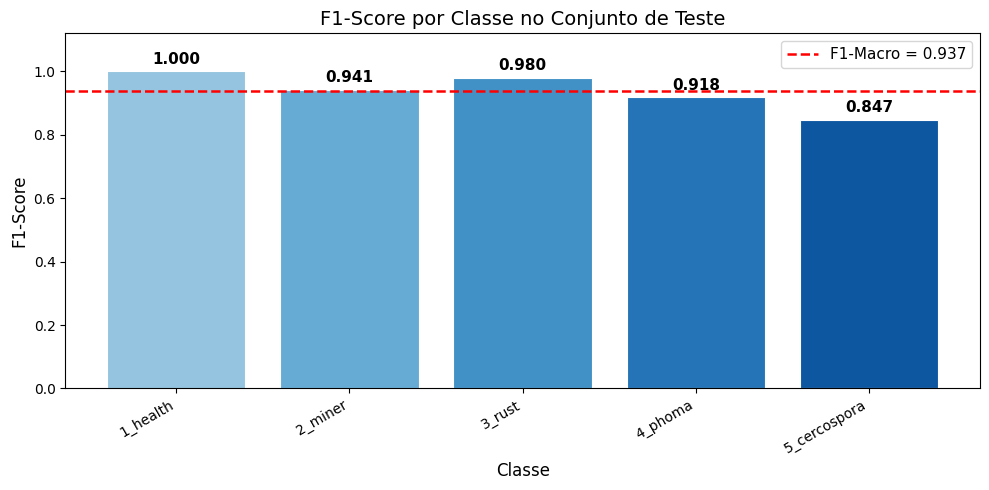

In [13]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize

n_classes = len(class_names_geral)
# Binariza os rótulos reais para avaliação one-vs-rest
y_true_bin = label_binarize(y_true_test, classes=list(range(n_classes)))

# ── Curvas ROC e Precision-Recall ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, class_name in enumerate(class_names_geral):
    # ROC
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC={roc_auc:.2f})')

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs_test[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_pred_probs_test[:, i])
    axes[1].plot(recall, precision, linewidth=2, label=f'{class_name} (AP={ap:.2f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatório')
axes[0].set_title('Curvas ROC por Classe (One-vs-Rest)', fontsize=13)
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Curvas Precision-Recall por Classe', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'curvas_roc_pr_{NOME_ARQUIVO}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── F1-Score por Classe (Gráfico de Barras) ────────────────────────────────
f1_por_classe = f1_score(y_true_test, y_pred_test, average=None)
f1_macro = f1_score(y_true_test, y_pred_test, average='macro')

plt.figure(figsize=(10, 5))
cores = plt.cm.Blues(np.linspace(0.4, 0.85, n_classes))
bars = plt.bar(class_names_geral, f1_por_classe, color=cores, edgecolor='white', linewidth=0.8)
plt.axhline(y=f1_macro, color='red', linestyle='--', linewidth=1.8, label=f'F1-Macro = {f1_macro:.3f}')

for bar, val in zip(bars, f1_por_classe):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('F1-Score por Classe no Conjunto de Teste', fontsize=14)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.12)
plt.legend(fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'f1_por_classe_{NOME_ARQUIVO}.png', dpi=150, bbox_inches='tight')
plt.show()

# Estrutura Base para o Grad-CAM

In [14]:
# CÉLULA 10: Inteligência Artificial Explicável (Grad-CAM)
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Encontrar o índice exato onde o backbone está inserido no modelo
    #    O backbone sempre recebe o nome fixo "base_model" em create_model()
    base_model_idx = model.layers.index(model.get_layer("base_model"))

    # 2. Executar as camadas iniciais (o pré-processamento) manualmente
    x = img_array
    for layer in model.layers[:base_model_idx]:
        # Ignoramos a InputLayer, pois ela é apenas um "placeholder"
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        x = layer(x)

    # 3. Resgatar o extrator de características (backbone)
    base_model = model.layers[base_model_idx]

    # 4. Abrir a gravação de gradientes do TensorFlow
    with tf.GradientTape() as tape:
        # Passamos a imagem pré-processada pelo modelo base
        # Como usamos include_top=False, a saída JÁ É o mapa de características convolucional final!
        feature_maps = base_model(x, training=False)

        # Dizer expressamente ao TensorFlow para monitorar essa variável
        tape.watch(feature_maps)

        # Continuar passando a imagem pelas camadas restantes (Pooling, Denses, Dropout)
        out = feature_maps
        for layer in model.layers[base_model_idx + 1:]:
            out = layer(out, training=False)

        preds = out

        # Isolar a predição da classe de interesse
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5. Calcular os gradientes da classe predita em relação aos mapas de características
    grads = tape.gradient(class_channel, feature_maps)

    # 6. Agrupar os gradientes (Tirando a média espacial - Global Average Pooling dos gradientes)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Multiplicar cada canal de característica pelo seu "peso" de importância (o gradiente)
    feature_maps = feature_maps[0]
    heatmap = feature_maps @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. Aplicar ReLU (remover valores negativos) e normalizar a imagem do calor entre 0 e 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.5):
    # Carregar imagem original
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Redimensionar o heatmap para o tamanho da imagem
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Converter o heatmap para cores (padrão Jet)
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Sobrepor as imagens
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    superimposed_img = jet_heatmap * alpha + (img.astype("float32") / 255)
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # Visualizar
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagem Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM (Justificativa Visual)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

[1_health] Acertos: 38 | Erros: 0


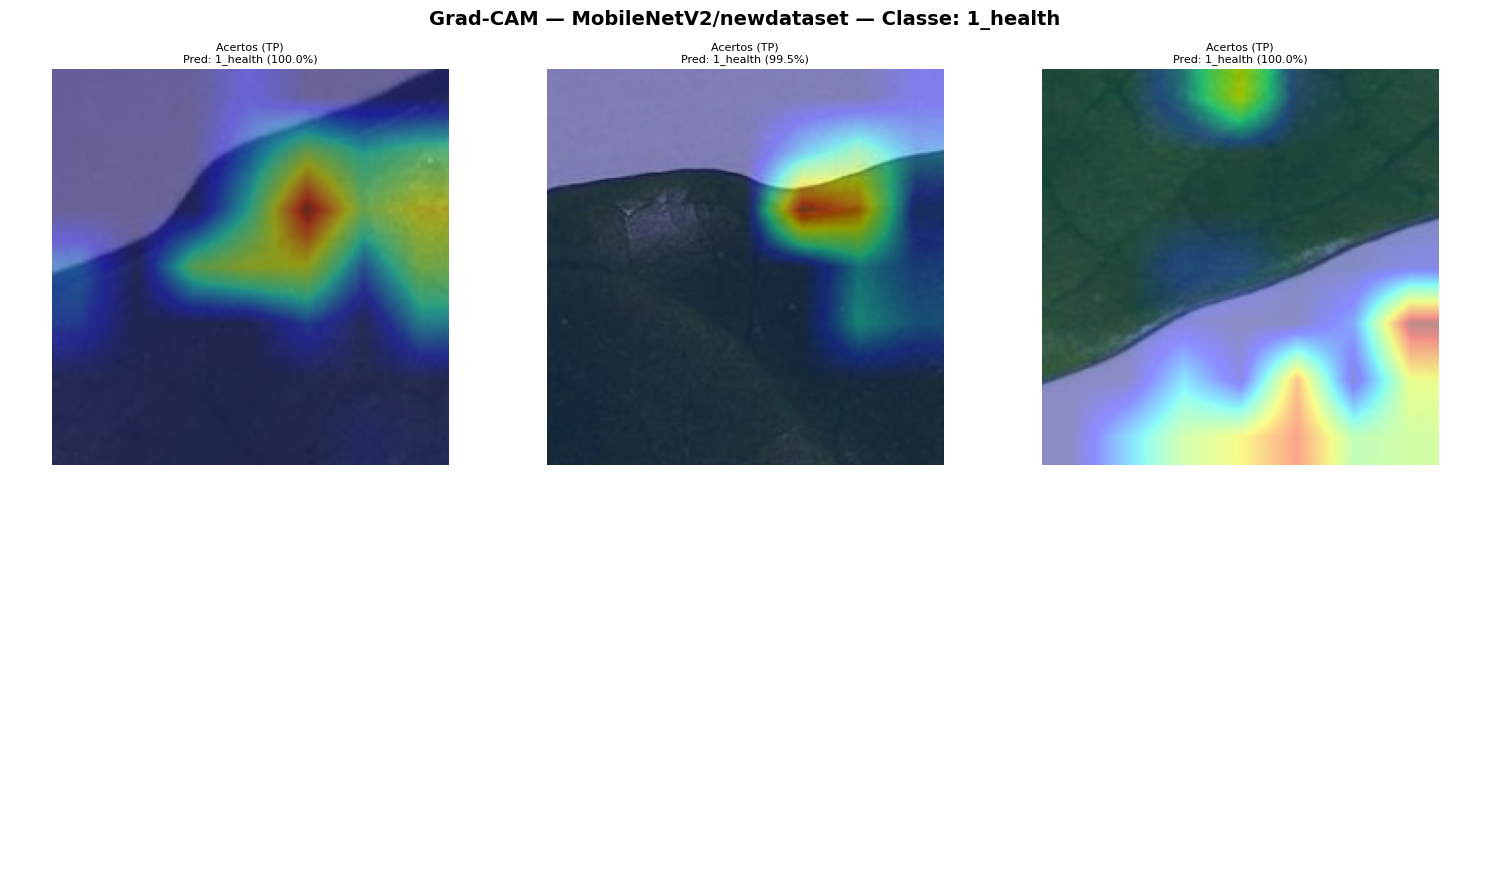

[2_miner] Acertos: 87 | Erros: 3


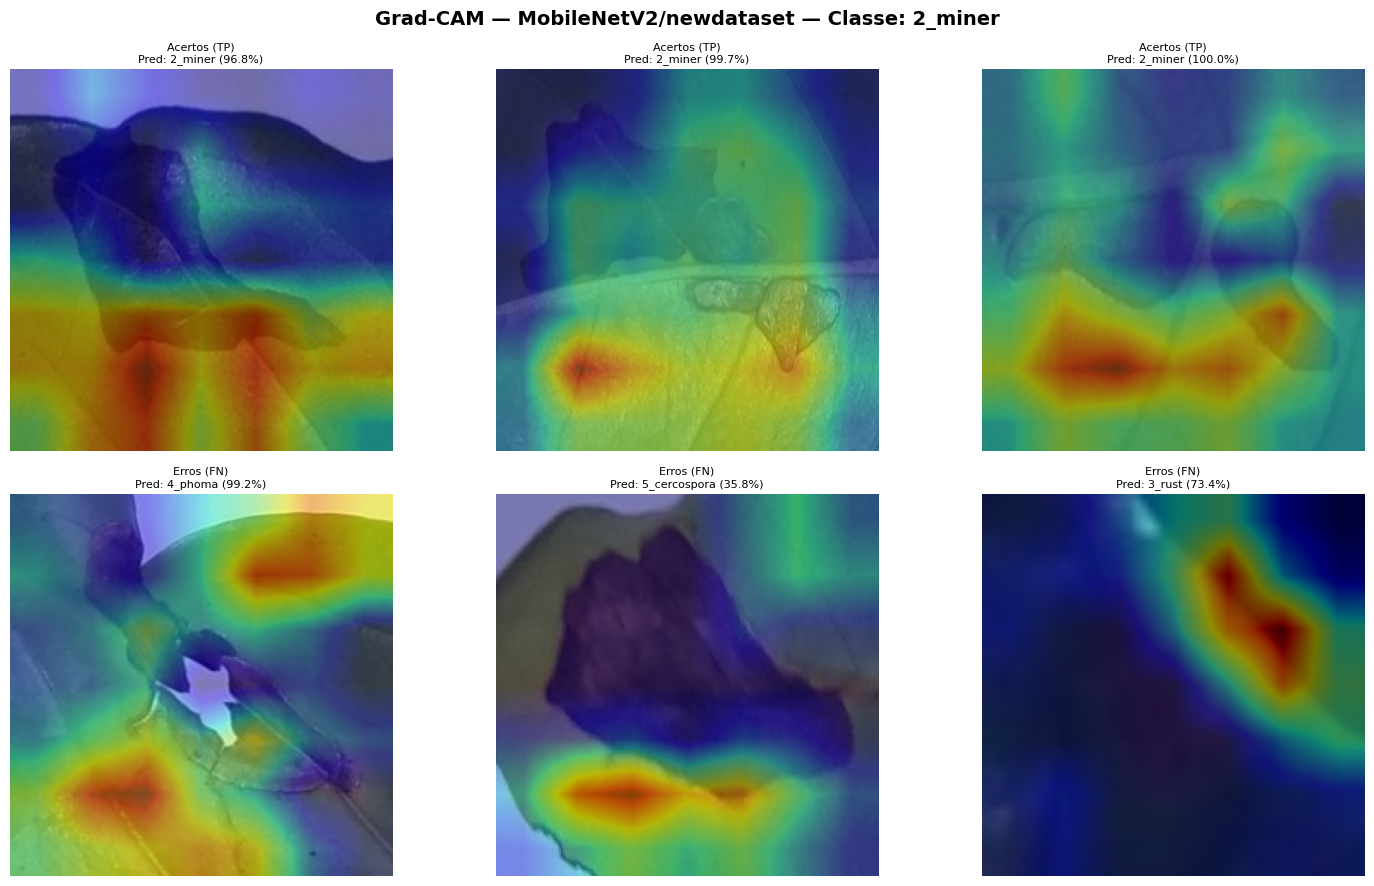

[3_rust] Acertos: 147 | Erros: 2


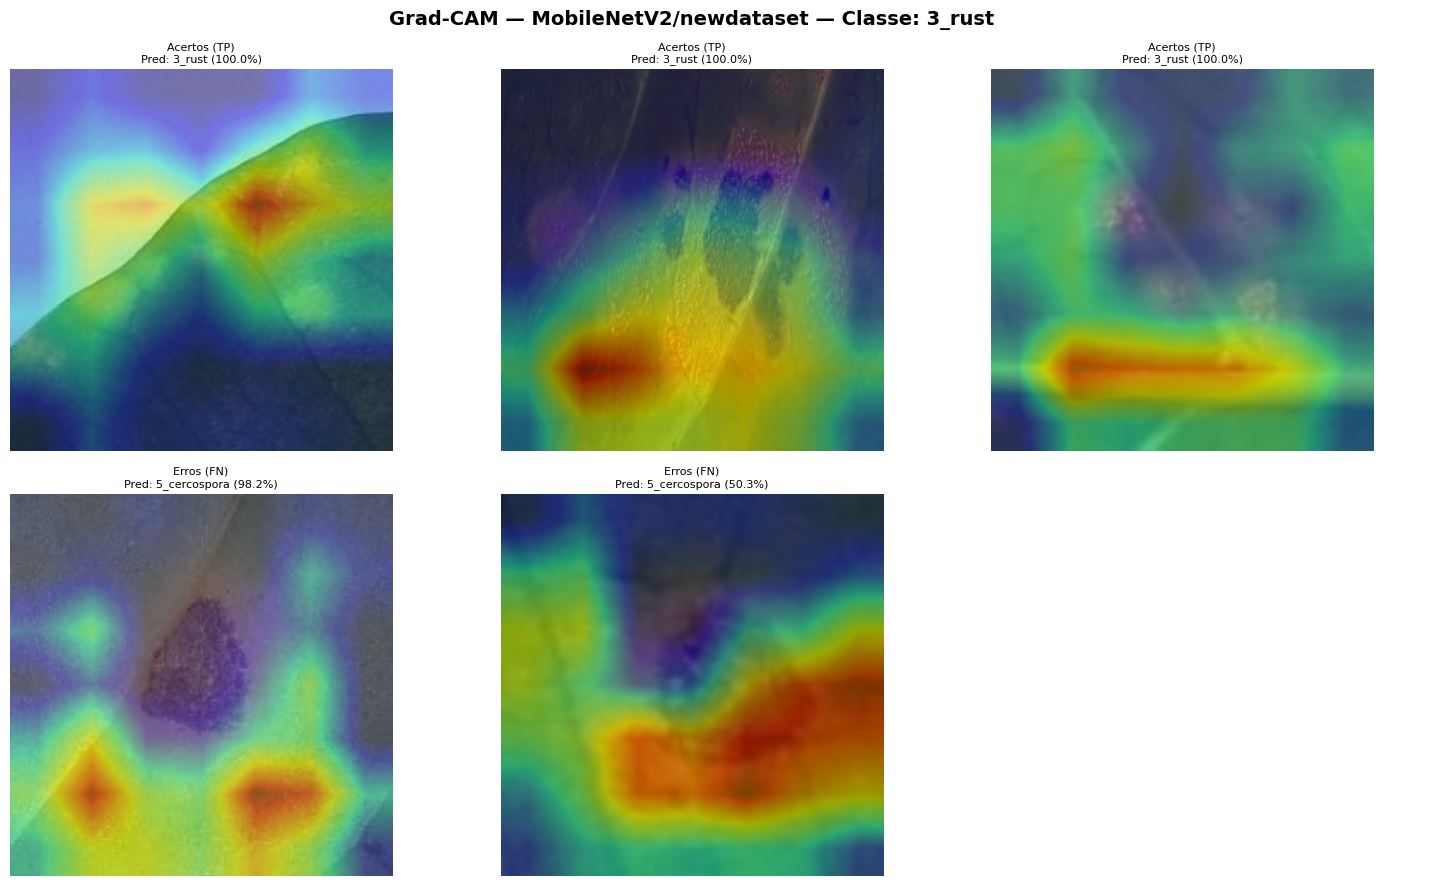

[4_phoma] Acertos: 67 | Erros: 8


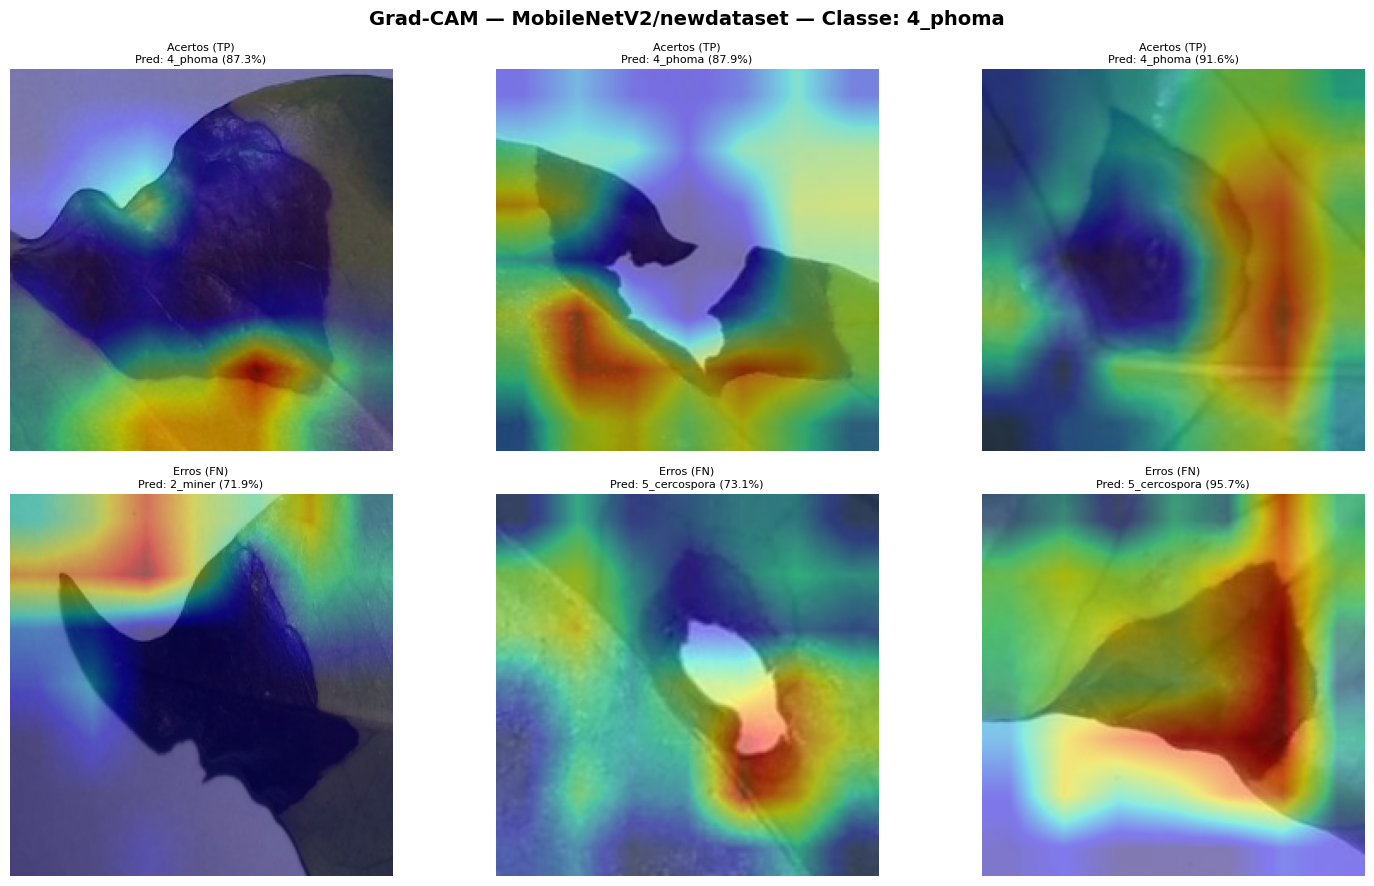

[5_cercospora] Acertos: 47 | Erros: 10


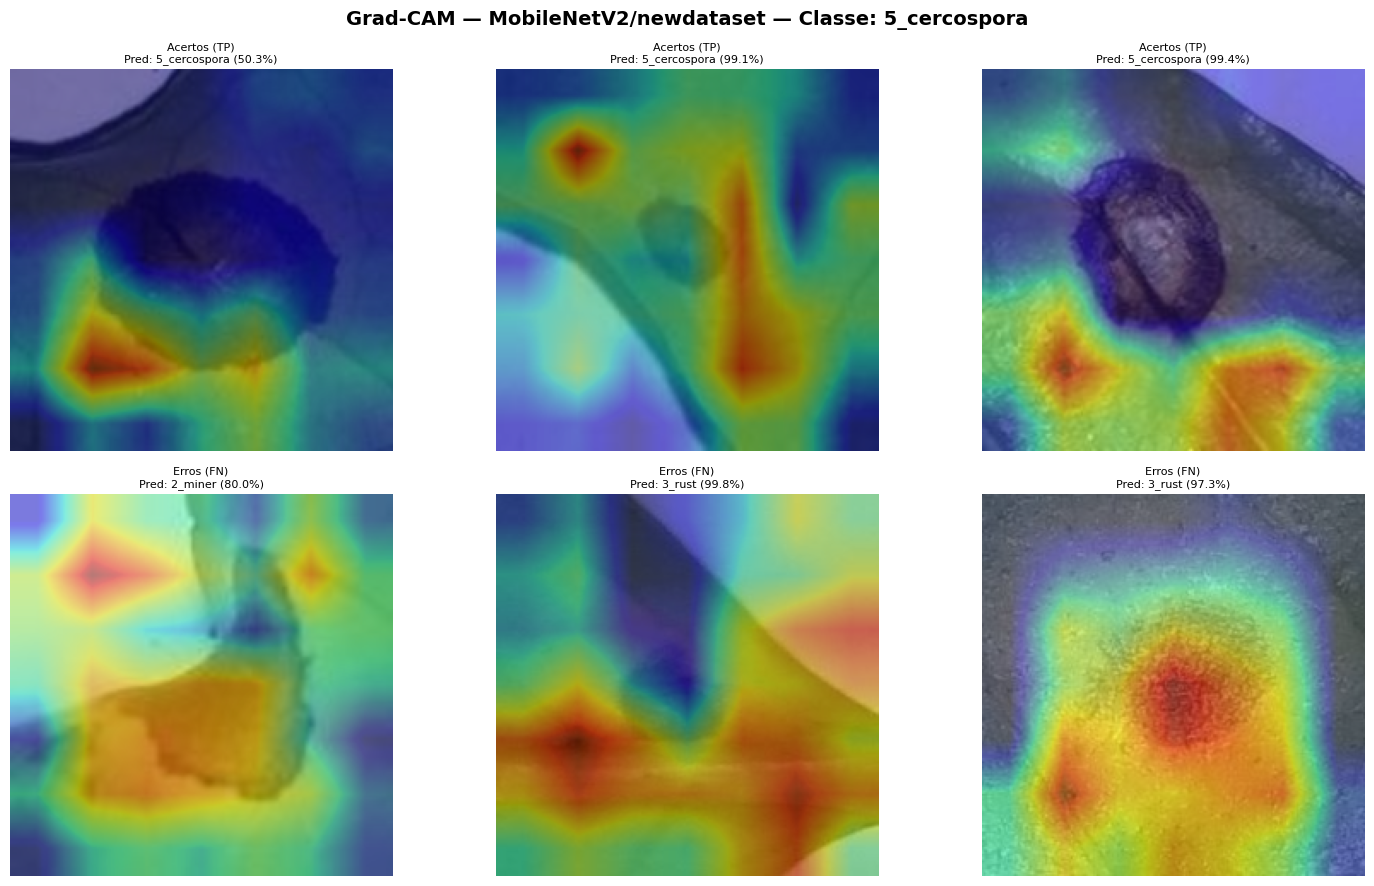

In [15]:
import cv2
import pathlib

N_POR_CLASSE = 3  # imagens exibidas por categoria (acertos e erros)

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def carregar_imagem(caminho, target_size=(224, 224)):
    """Carrega imagem do disco → (img_rgb uint8, img_array float32 com batch dim)."""
    img = cv2.imread(str(caminho))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, target_size)
    img_array = np.expand_dims(img_rgb.astype(np.float32), axis=0)
    return img_rgb, img_array

def gerar_overlay_gradcam(img_rgb, heatmap, alpha=0.45):
    """Sobrepõe o heatmap Grad-CAM sobre a imagem original."""
    hm = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    hm_uint8 = np.uint8(255 * hm)
    jet_colors = plt.colormaps.get_cmap("jet")(np.arange(256))[:, :3]
    overlay = jet_colors[hm_uint8] * alpha + img_rgb.astype(np.float32) / 255 * (1 - alpha)
    return np.clip(overlay, 0, 1)

# ── Mapeamento: arquivo → predição (mesma ordem do test_dataset shuffle=False) ──
all_test_info = []
for class_idx, class_name in enumerate(class_names_geral):
    class_dir = pathlib.Path(test_dir) / class_name
    img_files = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in IMG_EXTENSIONS])
    for img_path in img_files:
        all_test_info.append({'path': str(img_path), 'true_label': class_idx})

for i, info in enumerate(all_test_info):
    info['pred_label']  = int(y_pred_test[i])
    info['confidence']  = float(y_pred_probs_test[i, int(y_pred_test[i])])

# ── Grad-CAM em lote: acertos (TP) e erros (FN) por classe ─────────────────
for class_idx, class_name in enumerate(class_names_geral):
    acertos = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] == class_idx]
    erros   = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] != class_idx]

    samples_ok  = acertos[:N_POR_CLASSE]
    samples_err = erros[:N_POR_CLASSE]
    print(f"[{class_name}] Acertos: {len(acertos)} | Erros: {len(erros)}")

    fig, axes = plt.subplots(2, N_POR_CLASSE, figsize=(5 * N_POR_CLASSE, 9))
    fig.suptitle(f'Grad-CAM — {BACKBONE_ATIVO}/{DATASET_ATIVO} — Classe: {class_name}', fontsize=14, fontweight='bold')

    for row, (rotulo, samples) in enumerate([('Acertos (TP)', samples_ok), ('Erros (FN)', samples_err)]):
        for col in range(N_POR_CLASSE):
            ax = axes[row, col]
            if col < len(samples):
                d = samples[col]
                img_rgb, img_array = carregar_imagem(d['path'])
                heatmap = make_gradcam_heatmap(img_array, model)
                overlay = gerar_overlay_gradcam(img_rgb, heatmap)
                ax.imshow(overlay)
                pred_name = class_names_geral[d['pred_label']]
                ax.set_title(f"{rotulo}\nPred: {pred_name} ({d['confidence']*100:.1f}%)", fontsize=8)
            else:
                ax.set_facecolor('#eeeeee')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'gradcam_{NOME_ARQUIVO}_{class_name}.png', dpi=120, bbox_inches='tight')
    plt.show()

# XAI — LIME (Explicabilidade por Superpixels)


Gerando explicações LIME por classe (pode demorar alguns minutos)...


  0%|          | 0/1000 [00:00<?, ?it/s]

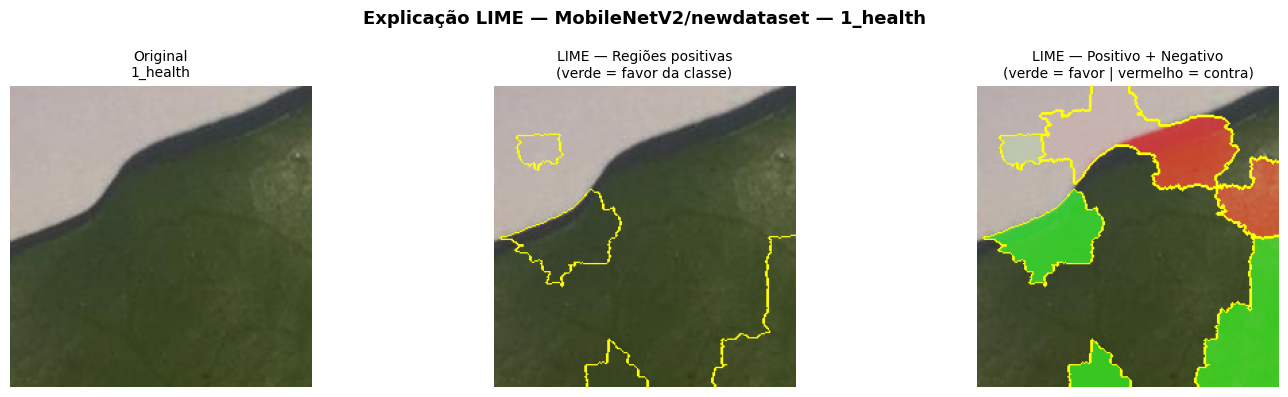

  [1_health] OK


  0%|          | 0/1000 [00:00<?, ?it/s]

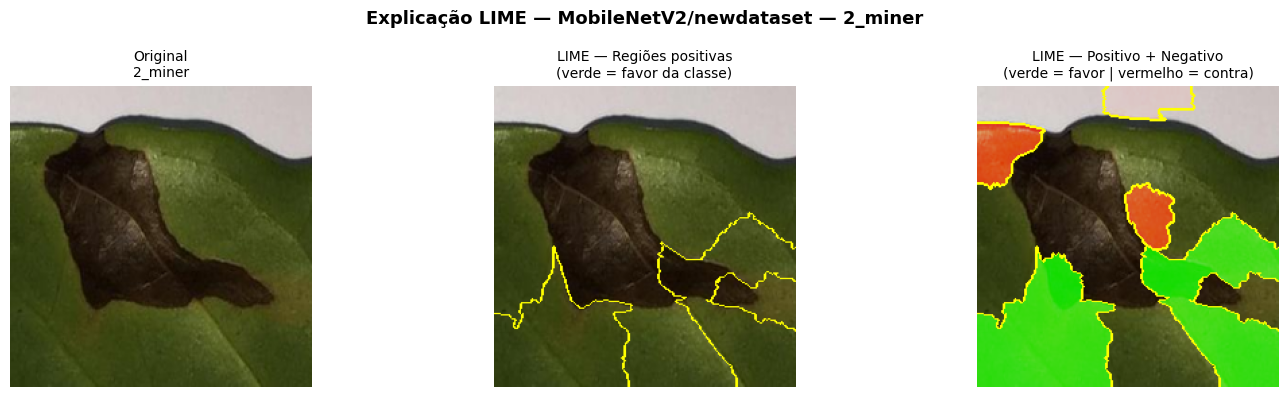

  [2_miner] OK


  0%|          | 0/1000 [00:00<?, ?it/s]

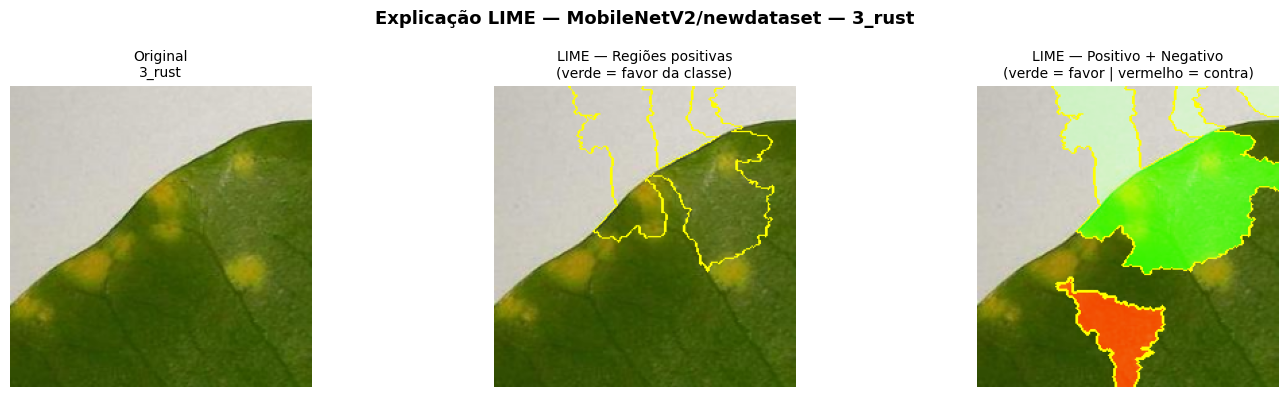

  [3_rust] OK


  0%|          | 0/1000 [00:00<?, ?it/s]

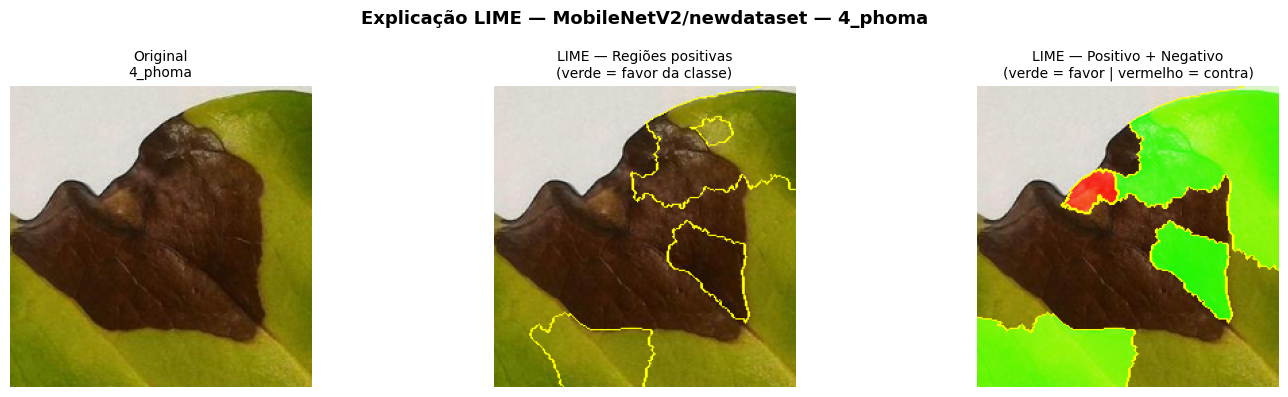

  [4_phoma] OK


  0%|          | 0/1000 [00:00<?, ?it/s]

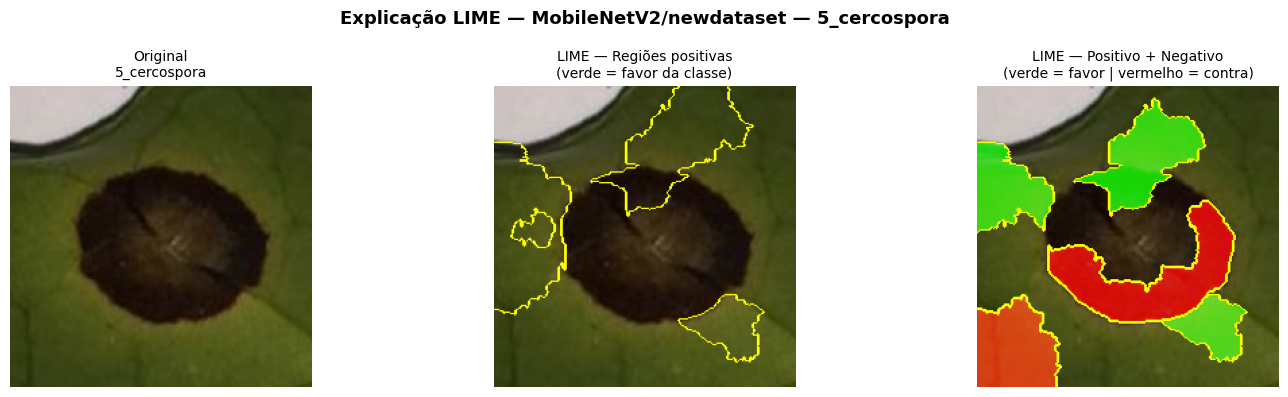

  [5_cercospora] OK


In [16]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def predict_fn_lime(images):
    """
    Wrapper de predição para o LIME.
    O LIME passa imagens no mesmo formato da entrada (uint8, 0-255).
    O modelo aplica preprocess_input internamente, então basta converter para float32.
    """
    return model.predict(images.astype(np.float32), verbose=0)

explainer_lime = lime_image.LimeImageExplainer(random_state=SEED)
N_LIME_SAMPLES = 1000  # perturbações por explicação (mais = mais preciso, mais lento)

print("Gerando explicações LIME por classe (pode demorar alguns minutos)...")
for class_idx, class_name in enumerate(class_names_geral):
    acertos = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] == class_idx]
    if not acertos:
        print(f"  [{class_name}] Sem acertos — pulando.")
        continue

    img_rgb, _ = carregar_imagem(acertos[0]['path'])

    explanation = explainer_lime.explain_instance(
        img_rgb,
        predict_fn_lime,
        top_labels=1,
        hide_color=0,
        num_samples=N_LIME_SAMPLES,
        random_seed=SEED,
    )

    # Regiões que contribuem positivamente para a classe predita
    temp_pos, mask_pos = explanation.get_image_and_mask(
        class_idx, positive_only=True, num_features=6, hide_rest=False
    )
    # Regiões positivas E negativas (visão completa)
    temp_all, mask_all = explanation.get_image_and_mask(
        class_idx, positive_only=False, num_features=10, hide_rest=False
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original\n{class_name}', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(mark_boundaries(temp_pos.astype(np.float32) / 255, mask_pos))
    axes[1].set_title('LIME — Regiões positivas\n(verde = favor da classe)', fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(mark_boundaries(temp_all.astype(np.float32) / 255, mask_all))
    axes[2].set_title('LIME — Positivo + Negativo\n(verde = favor | vermelho = contra)', fontsize=10)
    axes[2].axis('off')

    plt.suptitle(f'Explicação LIME — {BACKBONE_ATIVO}/{DATASET_ATIVO} — {class_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'lime_{NOME_ARQUIVO}_{class_name}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  [{class_name}] OK")

# XAI — Integrated Gradients (Feature Attribution)

Gerando explicações por Integrated Gradients por classe...


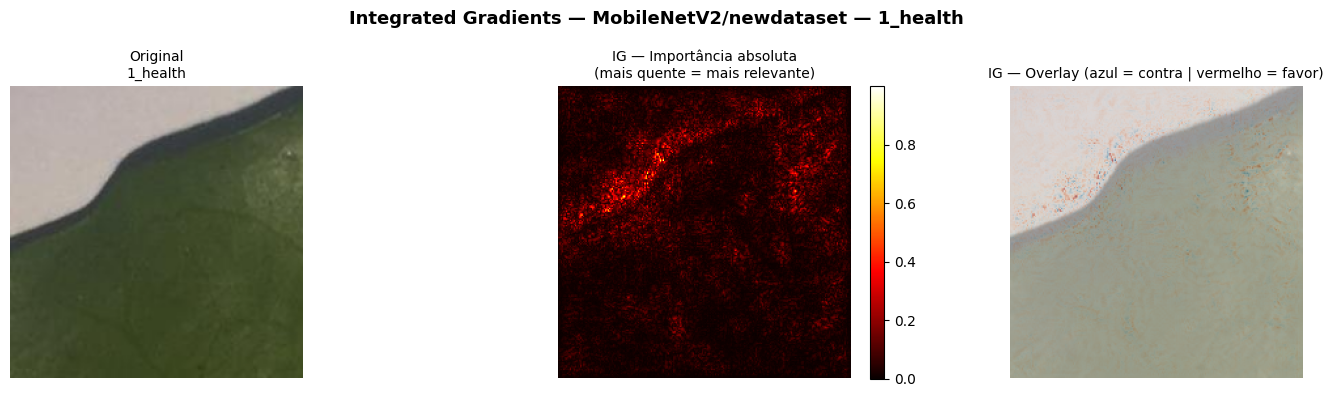

  [1_health] OK


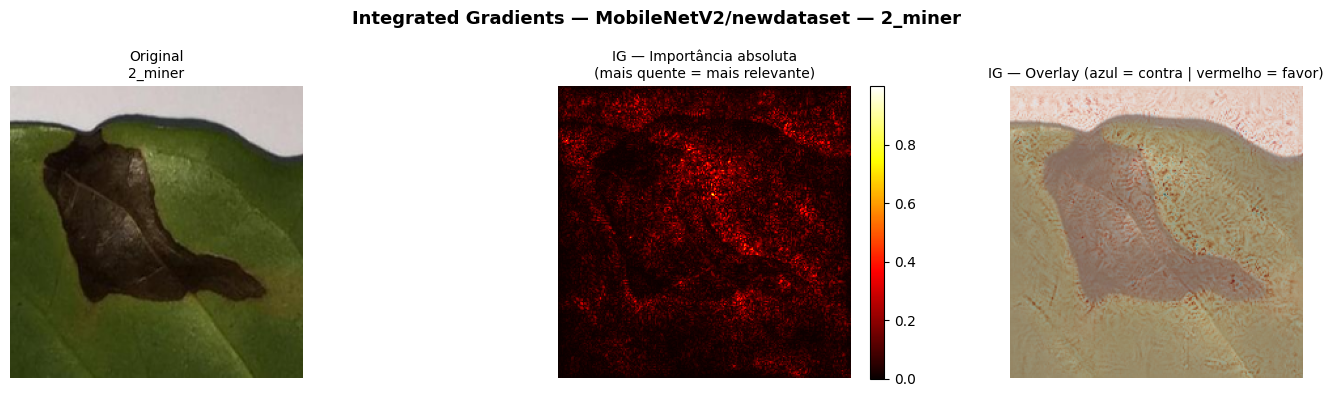

  [2_miner] OK


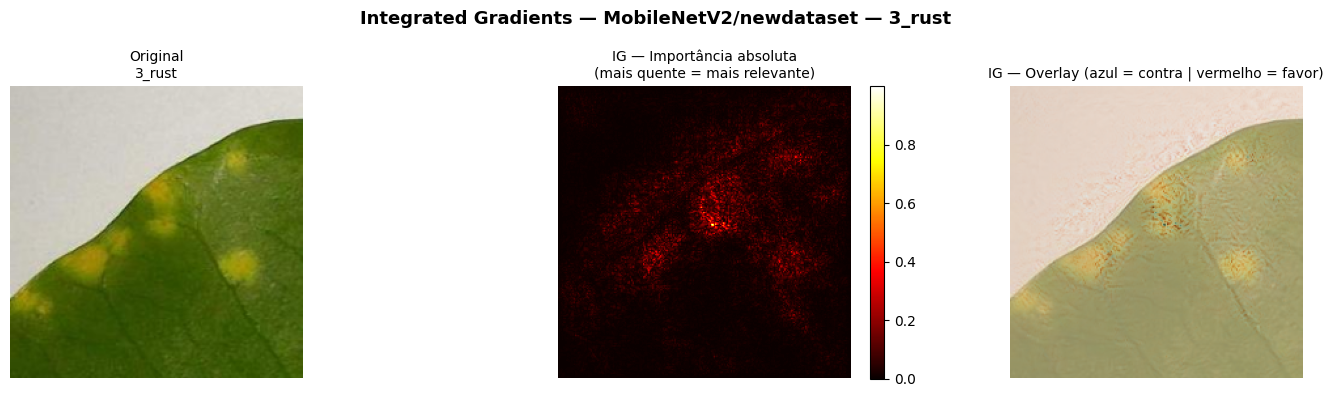

  [3_rust] OK


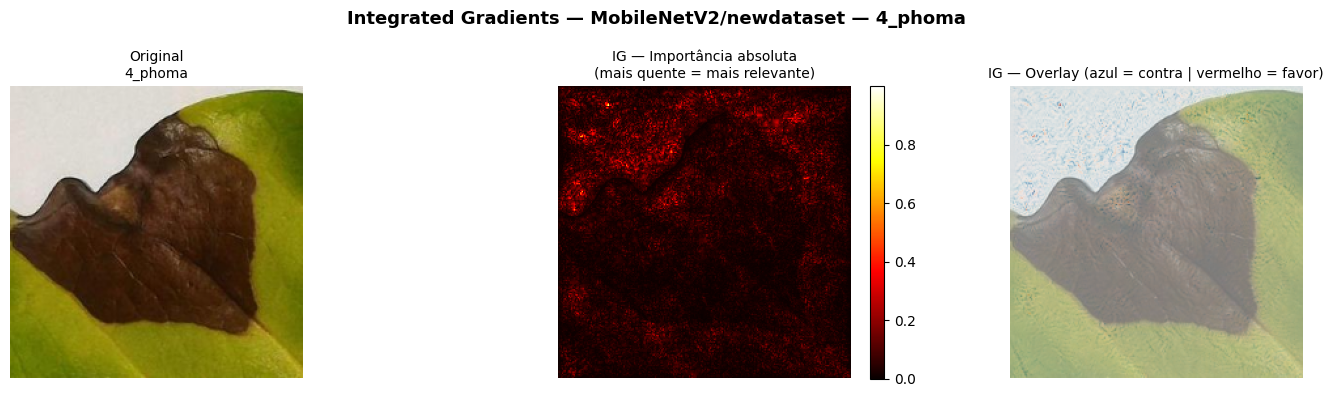

  [4_phoma] OK


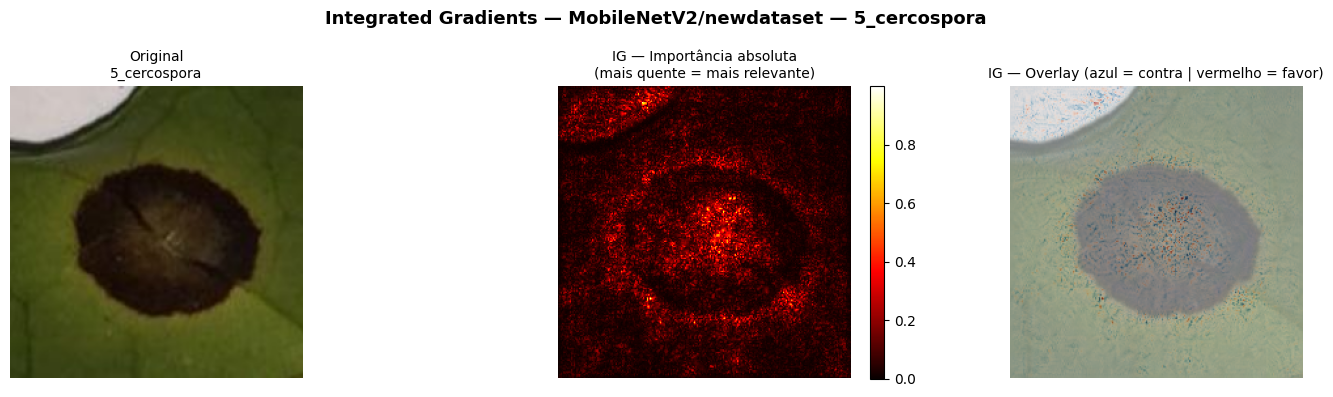

  [5_cercospora] OK


In [18]:

def integrated_gradients(model, img_array, class_idx, m_steps=50, batch_size=32):
    """
    Integrated Gradients (Sundararajan et al., 2017) — substituto ao SHAP GradientExplainer.
    Compatível com TF 2.16+ (não depende de tf.keras.backend.learning_phase).
    Baseline: imagem preta (zeros).
    """
    baseline = tf.zeros_like(img_array)                        # (1, 224, 224, 3)
    alphas   = tf.linspace(0.0, 1.0, m_steps + 1)             # m_steps+1 pontos

    # Interpola entre baseline e imagem de entrada
    interp = tf.concat(
        [baseline + a * (img_array - baseline) for a in alphas], axis=0
    )  # (m_steps+1, 224, 224, 3)

    # Calcula gradientes em mini-batches para evitar OOM
    all_grads = []
    for i in range(0, len(interp), batch_size):
        batch = tf.Variable(interp[i : i + batch_size])
        with tf.GradientTape() as tape:
            preds  = model(batch, training=False)
            target = preds[:, class_idx]
        all_grads.append(tape.gradient(target, batch))

    grads = tf.concat(all_grads, axis=0)                       # (m_steps+1, 224, 224, 3)

    # Integração pela regra do trapézio
    avg_grads = tf.reduce_mean((grads[:-1] + grads[1:]) / 2.0, axis=0, keepdims=True)

    # IG = (img − baseline) × gradiente médio
    ig = (img_array - baseline) * avg_grads
    return ig.numpy()[0]                                       # (224, 224, 3)


print("Gerando explicações por Integrated Gradients por classe...")
for class_idx, class_name in enumerate(class_names_geral):
    acertos = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] == class_idx]
    if not acertos:
        print(f"  [{class_name}] Sem acertos — pulando.")
        continue

    img_rgb, img_array = carregar_imagem(acertos[0]['path'])
    img_tensor = tf.constant(img_array, dtype=tf.float32)

    ig = integrated_gradients(model, img_tensor, class_idx)    # (224, 224, 3)

    # Mapa de importância absoluta (média dos canais RGB)
    ig_abs  = np.abs(ig).mean(axis=-1)                         # (224, 224)
    ig_norm = (ig_abs - ig_abs.min()) / (ig_abs.max() - ig_abs.min() + 1e-8)

    # Mapa de contribuição signed (positivo = favor, negativo = contra)
    ig_signed      = ig.mean(axis=-1)
    ig_signed_norm = (ig_signed - ig_signed.min()) / (ig_signed.max() - ig_signed.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original\n{class_name}', fontsize=10)
    axes[0].axis('off')

    im1 = axes[1].imshow(ig_norm, cmap='hot')
    axes[1].set_title('IG — Importância absoluta\n(mais quente = mais relevante)', fontsize=10)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    cmap_rdb = plt.colormaps.get_cmap('RdBu_r')
    ig_rgb   = cmap_rdb(ig_signed_norm)[:, :, :3]
    overlay  = ig_rgb * 0.5 + img_rgb.astype(np.float32) / 255 * 0.5
    axes[2].imshow(np.clip(overlay, 0, 1))
    axes[2].set_title('IG — Overlay (azul = contra | vermelho = favor)', fontsize=10)
    axes[2].axis('off')

    plt.suptitle(f'Integrated Gradients — {BACKBONE_ATIVO}/{DATASET_ATIVO} — {class_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'ig_{NOME_ARQUIVO}_{class_name}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  [{class_name}] OK")


# Validação Multi-Seed (Rigor Estatístico)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd

# Seeds adicionais treinadas com os MESMOS best_params vindos do Optuna — o objetivo
# é medir a variância do desempenho final (inicialização de pesos + embaralhamento),
# não buscar novos hiperparâmetros. O modelo canônico (SEED=42, já treinado acima) é
# reaproveitado para TFLite/latência/Grad-CAM/LIME/IG — não é retreinado aqui.
SEEDS_ADICIONAIS = [123, 2024]

def treinar_com_seed(seed, best_params, backbone_name=BACKBONE_ATIVO):
    """Treina o modelo final com uma seed distinta e retorna as métricas no conjunto de teste."""
    np.random.seed(seed)
    tf.random.set_seed(seed)
    K.clear_session()

    m = create_model(trial=None, is_final=True, best_params=best_params, backbone_name=backbone_name)
    aug_layer_seed = get_augmentation_layer(best_params=best_params)
    train_dataset_seed = apply_augmentation(train_dataset, aug_layer_seed)

    early_stop_seed = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr_seed = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)

    m.fit(
        train_dataset_seed,
        validation_data=val_dataset,
        epochs=100,
        callbacks=[early_stop_seed, reduce_lr_seed],
        verbose=0,
        class_weight=class_weights
    )

    y_true_seed = np.concatenate([y for x, y in test_dataset], axis=0)
    y_pred_probs_seed = m.predict(test_dataset, verbose=0)
    y_pred_seed = np.argmax(y_pred_probs_seed, axis=-1)

    metricas = {
        'seed':            seed,
        'accuracy':        accuracy_score(y_true_seed, y_pred_seed),
        'f1_macro':        f1_score(y_true_seed, y_pred_seed, average='macro'),
        'precision_macro': precision_score(y_true_seed, y_pred_seed, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true_seed, y_pred_seed, average='macro', zero_division=0),
    }

    K.clear_session()
    gc.collect()
    return metricas


# Reaproveita as métricas já calculadas para o modelo canônico (SEED=42) — não retreina
resultados_multiseed = [{
    'seed':            SEED,
    'accuracy':        test_acc,
    'f1_macro':        f1_score(y_true_test, y_pred_test, average='macro'),
    'precision_macro': precision_score(y_true_test, y_pred_test, average='macro', zero_division=0),
    'recall_macro':    recall_score(y_true_test, y_pred_test, average='macro', zero_division=0),
}]

for s in SEEDS_ADICIONAIS:
    print(f"Treinando com seed={s} ({BACKBONE_ATIVO} / {DATASET_ATIVO})...")
    resultados_multiseed.append(treinar_com_seed(s, best_params))
    print(f"  Concluído. Acurácia={resultados_multiseed[-1]['accuracy']:.4f} | F1-Macro={resultados_multiseed[-1]['f1_macro']:.4f}")

df_multiseed = pd.DataFrame(resultados_multiseed)
print("\n── Resultados por seed ──")
print(df_multiseed.to_string(index=False))

media_multiseed  = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].mean()
desvio_multiseed = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].std()

print(f"\n── Média ± Desvio-padrão ({len(df_multiseed)} seeds) ──")
for col in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    print(f"  {col:17s}: {media_multiseed[col]:.4f} ± {desvio_multiseed[col]:.4f}")

# Acumulação de Resultados para Tabela Comparativa

In [ ]:
# Coleta métricas do experimento atual (agregadas em SEED + SEEDS_ADICIONAIS) e adiciona à lista comparativa
tflite_path    = f'{NOME_ARQUIVO}.tflite'
tflite_size_mb = os.path.getsize(tflite_path) / (1024 ** 2) if os.path.exists(tflite_path) else None

resultados_comparativos.append({
    'Modelo':                BACKBONE_ATIVO,
    'Dataset':                DATASET_ATIVO,
    'Acurácia (méd)':         round(media_multiseed['accuracy'], 4),
    'Acurácia (dp)':          round(desvio_multiseed['accuracy'], 4),
    'F1-Macro (méd)':         round(media_multiseed['f1_macro'], 4),
    'F1-Macro (dp)':          round(desvio_multiseed['f1_macro'], 4),
    'Precision-Macro (méd)':  round(media_multiseed['precision_macro'], 4),
    'Recall-Macro (méd)':     round(media_multiseed['recall_macro'], 4),
    'N_seeds':                len(df_multiseed),
    'Lat. Keras (ms)':        round(latencia_media, 2),
    'Lat. TFLite (ms)':       round(lat_tflite_media, 2),
    'TFLite (MB)':            round(tflite_size_mb, 2) if tflite_size_mb else 'N/A',
})

print(f"Resultado de '{BACKBONE_ATIVO} × {DATASET_ATIVO}' registrado ({len(df_multiseed)} seeds). Total acumulado: {len(resultados_comparativos)}")

# Tabela Comparativa — Modelos × Datasets

In [ ]:
import pandas as pd

if resultados_comparativos:
    df_comp = pd.DataFrame(resultados_comparativos)
    df_comp = df_comp.sort_values('F1-Macro (méd)', ascending=False).reset_index(drop=True)

    print("=" * 75)
    print("  TABELA COMPARATIVA — Modelos × Datasets")
    print("=" * 75)
    print(df_comp.to_string(index=True))
    print("=" * 75)

    # Para adicionar outro experimento: altere BACKBONE_ATIVO / DATASET_ATIVO na célula
    # de setup e re-execute todas as células de treinamento e avaliação.

    # Salvar em CSV para uso externo (LaTeX, Word, etc.)
    df_comp.to_csv('resultados_comparativos.csv', index=False)
    print("\nTabela salva em: resultados_comparativos.csv")
else:
    print("Nenhum resultado registrado. Execute as células de treinamento e avaliação primeiro.")